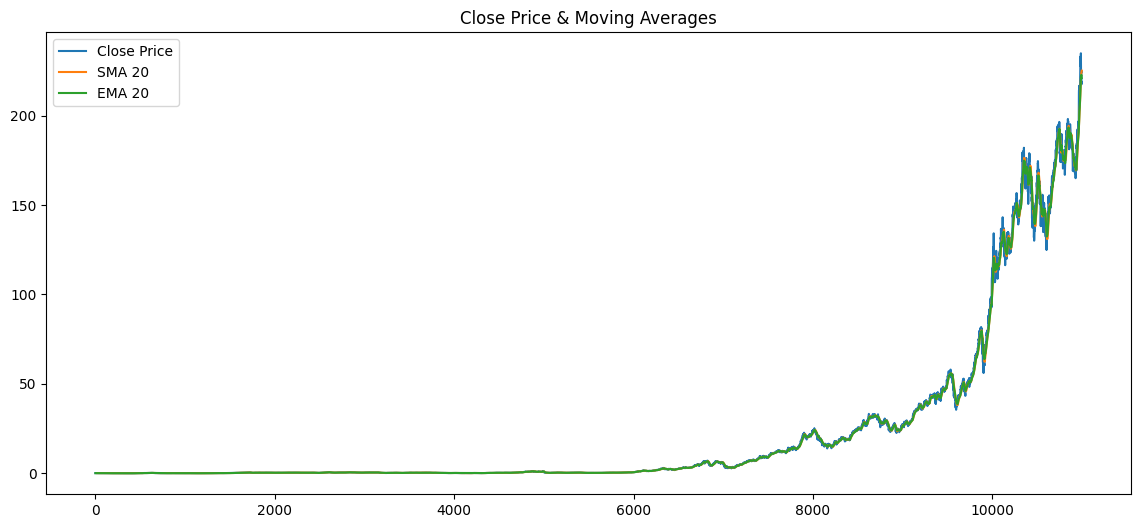

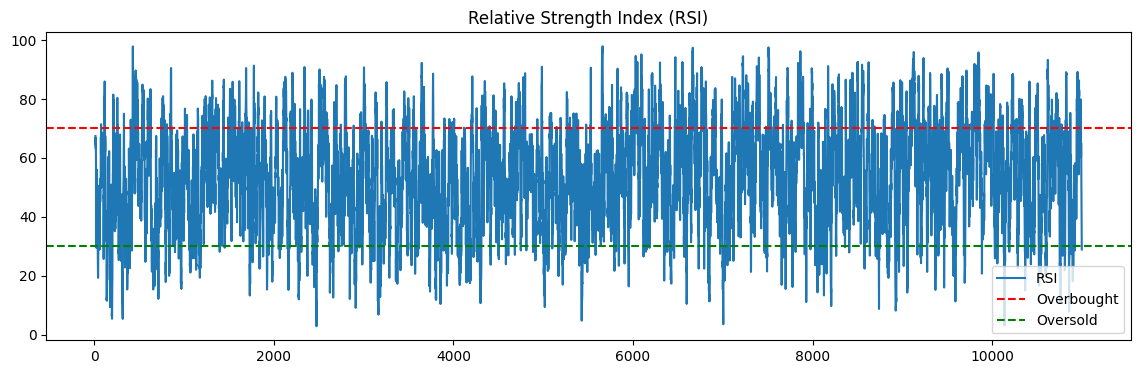

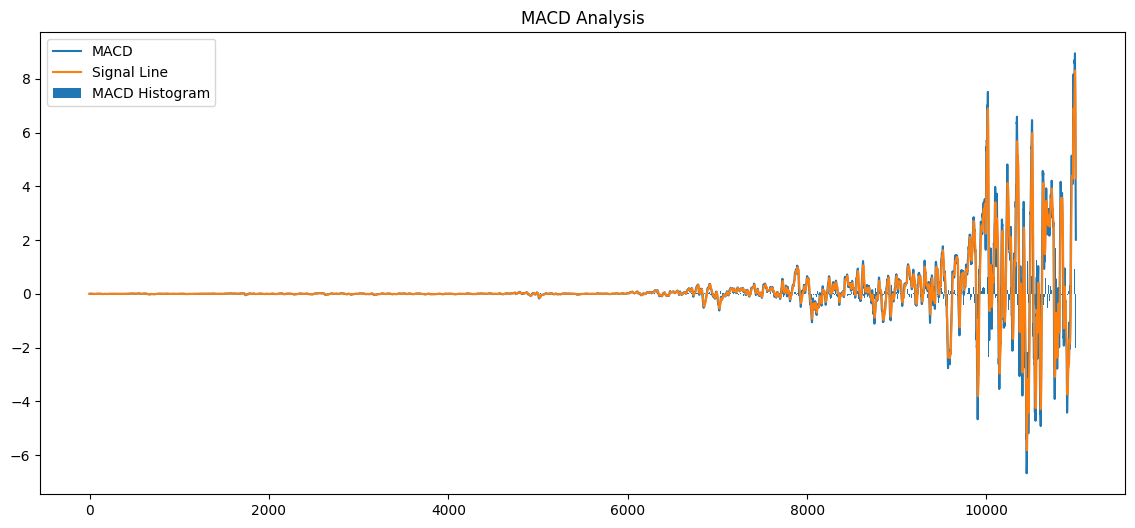

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../yfinance_data/AAPL_historical_data.csv")  # Replace "data.csv" with your actual file

# Calculate SMA 20
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# Calculate EMA 20
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

# Calculate RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD and related columns
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist'] = df['MACD'] - df['MACD_signal']

# Close Price + Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Close Price & Moving Averages")
plt.legend()
plt.show()

# RSI Plot
plt.figure(figsize=(14, 4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='r', linestyle='--', label='Overbought')
plt.axhline(30, color='g', linestyle='--', label='Oversold')
plt.title("Relative Strength Index (RSI)")
plt.legend()
plt.show()

# MACD Plot
plt.figure(figsize=(14, 6))
plt.plot(df['MACD'], label='MACD')
plt.plot(df['MACD_signal'], label='Signal Line')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Analysis")
plt.legend()
plt.show()
